<a href="https://colab.research.google.com/github/tifli/142a-project/blob/main/IOER_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression

In [2]:
K_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE = 0.2

## Import and Clean Dataset

In [3]:
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/tifli/142a-project/refs/heads/main/university_ranking.csv"
df = pd.read_csv(url)
df = df[df['year'] >= 2016]

# List of columns that should be numeric but might contain commas or percent signs
cols_to_clean = ['No. of FTE students', 'No. of students per staff',
                 'International students', 'International Outlook', 'Industry']

for col in cols_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('%', '').str.replace('-', ''), errors='coerce')

# Predicting Rank

## Split Dataset

In [4]:
TARGET = 'Rank'

X = df.drop(['Female:Male ratio', 'rank_prefix', TARGET], axis=1)
y = df[TARGET]

X_numeric = X.drop(['Name'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size = 0.2)

scaler = StandardScaler()

# Scale the encoded datasets and maintain DataFrame structure
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Construct train_data using the ORIGINAL X_train for OLS
train_data = pd.concat([X_train, y_train], axis=1)

**Note**

For training the models below, we do not use the 'Name' column as one-hot encoding would create over 300 dummy variables to capture all of the universities' names, leading to poor interpretability and increasing risk of overfitting.

##Linear Regression

In [5]:
ols = smf.ols(formula='Rank ~ Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Overall + Industry + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model_lr = ols.fit()
print(model_lr.summary())

# Predict using the unscaled X_test because the model was trained on unscaled train_data
y_pred = model_lr.predict(X_test)
SSE = np.sum((y_test - y_pred)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
osr_reduced = 1 - SSE/SST

print()
print(f"OSR-squared (reduced model): {osr_reduced}")

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     1111.
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        17:35:43   Log-Likelihood:                -7644.3
No. Observations:                1696   AIC:                         1.531e+04
Df Residuals:                    1686   BIC:                         1.536e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

### Computing VIF

In [6]:
vif_df = pd.DataFrame()
vif_df['features'] = X_numeric.columns
vif_df['VIF'] = [vif(X_numeric.values, i) for i in range(len(X_numeric.columns))]
print(vif_df)

                    features            VIF
0                       year     119.399432
1        No. of FTE students       5.488751
2  No. of students per staff       4.583517
3     International students      13.110441
4                    Overall  133311.527412
5                   Teaching    8629.533311
6       Research Environment    9415.256490
7           Research Quality   19947.129194
8                   Industry     160.216468
9      International Outlook    1021.017430


**Note**

Because 'Overall' has an extremely high VIF, we will remove this feature from the Linear Regression model.

### Reduced Model

In [7]:
ols = smf.ols(formula='Rank ~ Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Industry + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model_lr = ols.fit()
print(model_lr.summary())

# Predict using the unscaled X_test because the model was trained on unscaled train_data
y_pred = model_lr.predict(X_test)
SSE = np.sum((y_test - y_pred)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
osr_reduced = 1 - SSE/SST

print()
print(f"OSR-squared (reduced model): {osr_reduced}")

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     1157.
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        17:35:43   Log-Likelihood:                -7700.8
No. Observations:                1696   AIC:                         1.542e+04
Df Residuals:                    1687   BIC:                         1.547e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

**Note**

Because the R-squared and OSR-squared value changed by a small amount, we can drop the 'Overall' column and use this model since it simplified the feature space while not losing too much predictive power.

In [8]:
vif_df = pd.DataFrame()
X_numeric_reduced = X_numeric.drop(['Overall'], axis=1)
vif_df['features'] = X_numeric_reduced.columns
vif_df['VIF'] = [vif(X_numeric_reduced.values, i) for i in range(len(X_numeric_reduced.columns))]
print(vif_df)

                    features         VIF
0                       year  113.718836
1        No. of FTE students    5.374841
2  No. of students per staff    4.538650
3     International students   13.105214
4                   Teaching   94.996561
5       Research Environment   85.414698
6           Research Quality   67.483161
7                   Industry   11.707532
8      International Outlook   53.510644


**Note**

While some of the features retain high VIF values, they are significantly less than the previous model, so we decide to maintain the current feature space as these factors are relevant in determining the rank of a university in the real world. Moreover, 'Overall' score is just a generalization of those features.

In [9]:
X_train_reduced = X_train.drop(['Overall'], axis=1)
X_test_reduced = X_test.drop(['Overall'], axis=1)

### Residual Plot

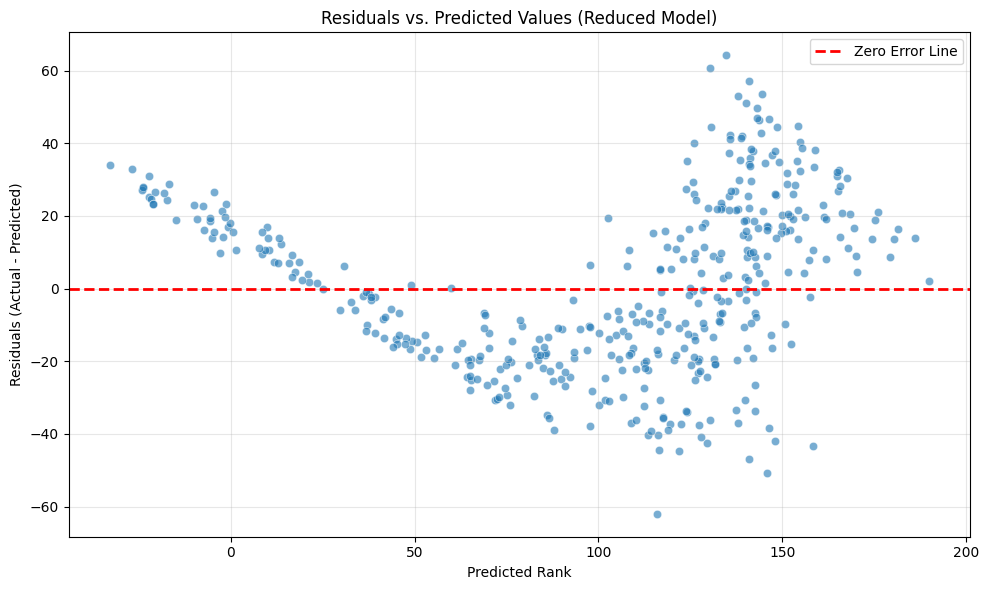

In [10]:
residuals = y_test - y_pred

# Create residual plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Error Line')
plt.title('Residuals vs. Predicted Values (Reduced Model)')
plt.xlabel('Predicted Rank')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Note**

While the out-of-sample for Linear Regression is quite high (0.85), the above residual plot indicates that the best fit line for capturing the relationship between the features and the target (Rank) is non-linear. Hence, Linear Regression may not be the best model for this dataset, but it serves as a good baseline for the others.

## Ridge Regression

In [11]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(cv=10, scoring='neg_mean_squared_error').fit(X_train_scaled, y_train)

print(f"Best lambda: {ridge_cv.alpha_}")

y_pred_l2 = ridge_cv.predict(X_test_scaled)
SSE = np.sum((y_test - y_pred_l2)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
OSR2_l2 = 1 - (SSE/SST)

print(f"OSR2 = {OSR2_l2}")

print("\nRegression coefficients:")
ridge_coefs = pd.Series(ridge_cv.coef_, index=X_train.columns)
print(ridge_coefs.head(20))

Best lambda: 0.1
OSR2 = 0.8634207167590285

Regression coefficients:
year                           9.587466
No. of FTE students           -3.160762
No. of students per staff      0.858325
International students        -4.570645
Overall                      101.208202
Teaching                     -56.033766
Research Environment         -82.881513
Research Quality             -45.402675
Industry                      -9.949446
International Outlook        -13.279602
dtype: float64


**Note**

We will also test removing the 'Overall' feature from Ridge Regression, similar to the Linear Regression model above.

In [12]:
X_train_scaled_reduced = X_train_scaled.drop(['Overall'], axis=1)
X_test_scaled_reduced = X_test_scaled.drop(['Overall'], axis=1)

ridge_cv = RidgeCV(cv=10, scoring='neg_mean_squared_error').fit(X_train_scaled_reduced, y_train)

print(f"Best lambda: {ridge_cv.alpha_}")

y_pred_l2 = ridge_cv.predict(X_test_scaled_reduced)
SSE = np.sum((y_test - y_pred_l2)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
OSR2_l2 = 1 - (SSE/SST)

print(f"OSR2 = {OSR2_l2}")

print("\nRegression coefficients:")
ridge_coefs = pd.Series(ridge_cv.coef_, index=X_train_reduced.columns)
print(ridge_coefs.head(20))

Best lambda: 1.0
OSR2 = 0.8617124882460577

Regression coefficients:
year                         10.492583
No. of FTE students          -3.102313
No. of students per staff     0.730228
International students       -4.613212
Teaching                    -12.253657
Research Environment        -35.416069
Research Quality            -15.803495
Industry                     -4.054036
International Outlook        -0.980005
dtype: float64


**Note**

Similar to Linear Regression, we should drop the 'Overall' column as the OSR-squared value did not get affected at all.

### Comparison (Linear Regression vs. Ridge)

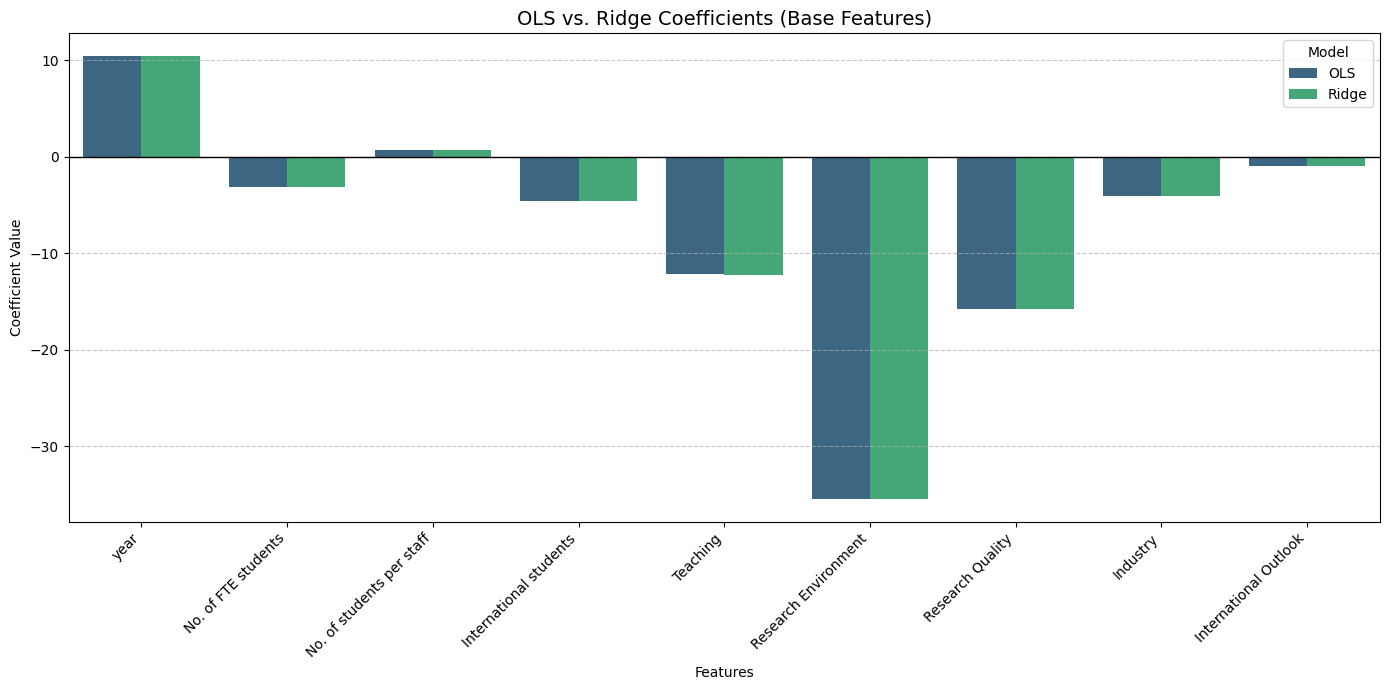

In [13]:
# Fit standard OLS on the scaled data for a fair comparison with Ridge
from sklearn.linear_model import LinearRegression

ols_scaled = LinearRegression().fit(X_train_scaled_reduced, y_train)

# Create a DataFrame with the features and their corresponding coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_reduced.columns,
    'OLS': ols_scaled.coef_,
    'Ridge': ridge_cv.coef_
})

# Melt the DataFrame to make it compatible with Seaborn's hue parameter
coef_df_melted = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting
plt.figure(figsize=(14, 7))
sns.barplot(data=coef_df_melted, x='Feature', y='Coefficient', hue='Model', palette='viridis')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.title('OLS vs. Ridge Coefficients (Base Features)', fontsize=14)
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

Since none of the regression coefficients are close to zero, all of the features are important for the model. Thus, we will try using PCA to combine features that are highly correlated with each.

##PCA

In [14]:
from sklearn.decomposition import PCA

# Use the one-hot encoded dataset to include categorical variables
X_train_pca_input = X_train_reduced

# Candidate numbers of principal components
max_components = min(X_train_pca_input.shape[1], 30)
component_grid = list(range(1, max_components + 1))

# K-fold CV object
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}

for k in component_grid:
    fold_R_sq = []

    for train_idx, val_idx in kf.split(X_train_pca_input):
        # Split the training data into one training fold and one validation fold
        X_tr = X_train_pca_input.iloc[train_idx]
        X_val = X_train_pca_input.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Fit PCA only on the training fold
        pca = PCA(n_components=k)
        X_tr_pca = pca.fit_transform(X_tr)
        X_val_pca = pca.transform(X_val)

        # Fit linear regression on the PCA-transformed training fold
        lr = LinearRegression()
        lr.fit(X_tr_pca, y_tr)

        # Predict on the validation fold
        R = lr.score(X_val_pca, y_val)
        fold_R_sq.append(R)

    # Store the mean CV R-squared for this k
    cv_scores[k] = np.mean(fold_R_sq)
    print(f"k = {k:2d}, mean = {cv_scores[k]:.4f}")

k =  1, mean = -0.0024
k =  2, mean = 0.5136
k =  3, mean = 0.7056
k =  4, mean = 0.7936
k =  5, mean = 0.7930
k =  6, mean = 0.8361
k =  7, mean = 0.8360
k =  8, mean = 0.8456
k =  9, mean = 0.8653


In [15]:
# Choose the best number of components
best_k = max(cv_scores, key=cv_scores.get)
print("\nBest number of principal components:", best_k)
print("Best mean CV R-squared:", cv_scores[best_k])


Best number of principal components: 9
Best mean CV R-squared: 0.8652632962628377


In [16]:
# Refit on the full training set using best_k
pca_best = PCA(n_components=best_k)
X_train_pca_best = pca_best.fit_transform(X_train_reduced)
X_test_pca_best = pca_best.transform(X_test_reduced)

lr_best = LinearRegression()
lr_best.fit(X_train_pca_best, y_train)

train_R_sq = lr_best.score(X_train_pca_best, y_train)
test_R_sq = lr_best.score(X_test_pca_best, y_test)

print("\nFinal model results")
print("Train R-squared:", round(train_R_sq, 4))
print("Test R-squared :", round(test_R_sq, 4))


Final model results
Train R-squared: 0.8674
Test R-squared : 0.8612


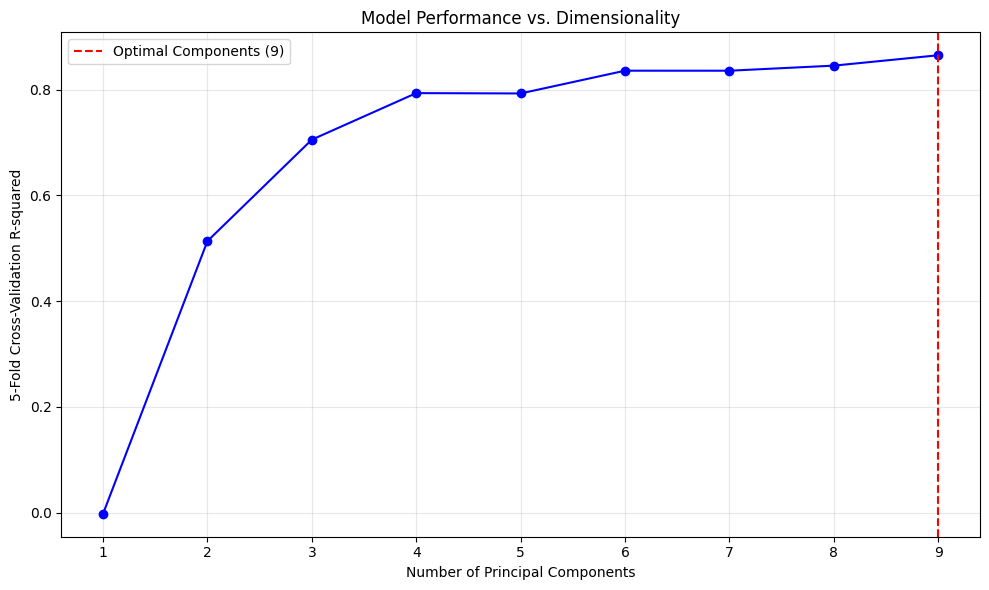

In [17]:
# --- VISUALIZATION: Cross-Validation R-squared Curve ---
mean_test_scores = [cv_scores[k] for k in component_grid]

plt.figure(figsize=(10, 6))
plt.plot(component_grid, mean_test_scores, marker='o', linestyle='-', color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal Components ({best_k})')
plt.xlabel('Number of Principal Components')
plt.ylabel(f'5-Fold Cross-Validation R-squared')
plt.title('Model Performance vs. Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Summary**

The fact that PCA uses all of the components for predictions and maintained a high R-squared value on the test set indicates that while the features are highly correlated to each other, they still play a significant role in determining the university's rank.

## CatBoost

In [18]:
import sys
!{sys.executable} -m pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [19]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

cb = CatBoostRegressor(verbose=0)

# Cross-validation
param_grid = {'iterations': [100, 300, 500],
              'learning_rate': [0.01, 0.03, 0.05],
              'depth': [4, 6, 8]}
grid_search = GridSearchCV(cb, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train_reduced, y_train)

print(grid_search.best_params_)
cb_best = grid_search.best_estimator_

{'depth': 6, 'iterations': 500, 'learning_rate': 0.05}


In [20]:
y_train_pred_catboost = cb_best.predict(X_train_reduced)
y_test_pred_catboost = cb_best.predict(X_test_reduced)

print("=== CatBoost ===")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_catboost)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred_catboost)))

SSE_cb = np.sum((y_test - y_test_pred_catboost)**2)
SST_cb = np.sum((y_test - np.mean(y_train))**2)
osr2_cb = 1 - (SSE_cb / SST_cb)
print("Test OSR2 :", osr2_cb)


=== CatBoost ===
Train RMSE: 2.6408108982343976
Test RMSE : 5.882576935906438
Test OSR2 : 0.9899433762562141


In [21]:
# Feature Importances
importances_cb = cb_best.get_feature_importance()
sorted_idx = np.argsort(importances_cb)[::-1]
for i in sorted_idx:
  print(f"{X_train.columns[i]}: {importances_cb[i]:.4f}")

Teaching: 43.0324
Research Environment: 23.7352
Overall: 15.3864
year: 8.8837
Industry: 3.2151
International students: 2.2937
No. of students per staff: 1.5747
No. of FTE students: 0.9903
Research Quality: 0.8884


# Predicting Overall Score

In [22]:
TARGET = 'Overall'

X_sub = df.drop(['Female:Male ratio', 'rank_prefix', TARGET], axis=1)
y_sub = df[TARGET]

X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_sub, y_sub, test_size = 0.2)

train_data_sub = pd.concat([X_train_sub, y_train_sub], axis=1)

## Linear Regression

In [23]:
ols = smf.ols(formula='Overall ~ Rank + Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Industry + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data_sub)
model_lr_sub = ols.fit()
print(model_lr_sub.summary())

# Predict using the unscaled X_test because the model was trained on unscaled train_data
y_pred_sub = model_lr_sub.predict(X_test_sub)
SSE = np.sum((y_test_sub - y_pred_sub)**2)
SST = np.sum((y_test_sub - np.mean(y_train_sub))**2)
osr_sub = 1 - SSE/SST

print()
print(f"OSR-squared: {osr_sub}")

                            OLS Regression Results                            
Dep. Variable:                Overall   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.449e+05
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        17:39:58   Log-Likelihood:                 501.44
No. Observations:                1696   AIC:                            -982.9
Df Residuals:                    1686   BIC:                            -928.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

**Note**

A perfect R-squared value of 1.0 and an out-of-sample R-squared value that is extremely close to 1.0 indicates that the Linear Regression model has found a deterministic relationship between the features and the "Overall" score, meaning that there's it found the exact formula for the target.

Hence, we do not need a Ridge model since its penalty can unnecessarily shrink important features, slightly distorting the calculation of the scores.

Furthermore, since 'Overall' score is a mathematical formulation, CatBoost will not be able to capture this formula as it was designed to find complex, non-linear relationships. In simple terms, CatBoost is "too advanced" for finding a simple formula to compute the 'Overall' score.

# Dashboard Creation

In [24]:
!pip install dash dash-bootstrap-components
import dash
from dash import dcc, html, Input, Output, State
import dash_bootstrap_components as dbc
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 6.7 MB/s eta 0:00:00


**Note**

PCA1 (Principal Component 1): This is the single new axis that captures the most variation among the universities. Often in ranking data, PCA1 represents a general "overall performance" score, summarizing the shared strength across most of the 5 main features.

PCA2 (Principal Component 2): This axis captures the second most variation and is completely independent of PCA1. It often represents a contrast or trade-off between certain features (for example, universities that score exceptionally high in Industry but lower in Teaching might separate out along this axis). In other words, thiis axis separates universities based on their unique strengths and weaknesses rather than just their total score.

In [25]:
# Get the latest year data
df_latest = df[df['year'] == df['year'].max()].copy()
main_feat = ['Teaching', 'Research Environment', 'Research Quality',
             'Industry', 'International Outlook']

# Create Rank Tiers
def get_tier(rank):
    if rank <= 50: return 'Top 50'
    elif rank <= 100: return '51-100'
    elif rank <= 200: return '101-200'
    else: return '201+'

df_latest['Rank_Tier'] = df_latest['Rank'].apply(get_tier)

# Calculate Peer Averages
peer_averages = df_latest.groupby('Rank_Tier')[main_feat].mean().reset_index()

# Prepare PCA on the 5 main features
pca_2 = PCA(n_components=2)
pca_coords = pca_2.fit_transform(df_latest[main_feat].fillna(df_latest[main_feat].mean()))
df_latest['PCA1'] = pca_coords[:, 0]
df_latest['PCA2'] = pca_coords[:, 1]

# Prepare coefficients dataframe (using previously fitted ols_scaled and ridge_cv)
coef_df_main = coef_df[coef_df['Feature'].isin(main_feat)]

### Build App

Predict "Overall" using the Linear Regression model (model_lr_sub) and "Rank" using CatBoost model (cb_best) since it achieves a higher out-of-sample R-squared value (0.9897) than Ridge Regression (0.8715).

In [26]:
# Prepare CatBoost Feature Importance Figure
cb_importance_df = pd.DataFrame({
    'Feature': X_train_reduced.columns,
    'Importance': importances_cb
}).sort_values(by='Importance', ascending=False)

fig_cb_importance = px.bar(cb_importance_df.head(10), x='Importance',
                           y='Feature', orientation='h',
                           title="CatBoost Top 10 Feature Importances for Determining Rank")
fig_cb_importance.update_layout(yaxis={'categoryorder': 'total ascending'})

app = dash.Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])
server = app.server  # Expose the server variable for deployments

dashboard_tab = html.Div([
    dbc.Card([
        dbc.CardBody([
            dbc.Row([
                dbc.Col([
                    html.Label("Select University:", className="fw-bold"),
                    dcc.Dropdown(
                        id='uni-dropdown',
                        options=[{'label': name, 'value': name} for name in df_latest['Name'].unique()],
                        value=df_latest['Name'].iloc[0],
                        className="mb-2"
                    )
                ], width=12)
            ])
        ])
    ], className="mb-4 shadow-sm"),

    dbc.Row([
        dbc.Col([dbc.Card([dbc.CardBody([dcc.Graph(id='radar-chart')])],
                          className="mb-4 shadow-sm")], width=6),
        dbc.Col([dbc.Card([dbc.CardBody([dcc.Graph(id='pca-plot')])],
                          className="mb-4 shadow-sm")], width=6)
    ]),

    dbc.Row([
        dbc.Col([dbc.Card([dbc.CardBody([dcc.Graph(id='weights-chart')])],
                          className="mb-4 shadow-sm")], width=6),
        dbc.Col([dbc.Card([dbc.CardBody([dcc.Graph(id='cb-importance-chart',
                                                   figure=fig_cb_importance)])],
                          className="mb-4 shadow-sm")], width=6)
    ]),

    dbc.Card([
        dbc.CardHeader(html.H3("Simulator: Adjust Feature Scores",
                               className="m-0 text-white bg-primary")),
        dbc.CardBody([
            html.Div(id='sliders-container'),
            html.Hr(),
            html.H4(id='simulator-output', className="mt-4 mb-2 text-center text-success fw-bold")
        ])
    ], className="mb-5 shadow-sm")
], className="mt-4")

resources_tab = html.Div([
    dbc.Card([
        dbc.CardHeader(html.H3("Resources", className="m-0 text-white bg-info")),
        dbc.CardBody([
            html.Ul([
                html.Li(html.A("The World University Rankings 2011-2026 Dataset (Kaggle)",
                               href="https://www.kaggle.com/datasets/cenxanane/the-world-university-rankings-2011-2026",
                               target="_blank", className="text-decoration-none fw-bold text-primary"))
            ])
        ])
    ], className="mt-4 shadow-sm")
])

app.layout = dbc.Container([
    dbc.Row([
        dbc.Col(html.H1("University Ranking Dashboard",
                        className="text-center text-primary my-4 fw-bold"),
                width=12)
    ]),

    dbc.Tabs([
        dbc.Tab(dashboard_tab, label="Dashboard"),
        dbc.Tab(resources_tab, label="Resources")
    ])

], fluid=True, className="bg-light py-3")

@app.callback(
    Output('radar-chart', 'figure'),
    Output('pca-plot', 'figure'),
    Output('weights-chart', 'figure'),
    Output('sliders-container', 'children'),
    Input('uni-dropdown', 'value')
)
def update_dashboard(selected_uni):
    # Radar Chart
    uni_data = df_latest[df_latest['Name'] == selected_uni].iloc[0]
    tier = uni_data['Rank_Tier']
    peer_data = peer_averages[peer_averages['Rank_Tier'] == tier].iloc[0]

    fig_radar = go.Figure()
    fig_radar.add_trace(go.Scatterpolar(
        r=[uni_data[p] for p in main_feat], theta=main_feat, fill='toself', name=selected_uni
    ))
    fig_radar.add_trace(go.Scatterpolar(
        r=[peer_data[p] for p in main_feat], theta=main_feat, fill='toself', name=f'{tier} Average'
    ))
    fig_radar.update_layout(title="Feature Scores vs. Peer Average",
                            polar=dict(radialaxis=dict(visible=True, range=[0, 100])))

    # PCA Plot
    fig_pca = px.scatter(df_latest, x='PCA1', y='PCA2', color='Rank_Tier',
                         hover_name='Name', title="University Clusters based on Features",
                         labels={'PCA1': 'Overall Performance', 'PCA2': 'Feature Contrast'})
    fig_pca.add_trace(go.Scatter(x=[uni_data['PCA1']], y=[uni_data['PCA2']],
                                 mode='markers',
                                 marker=dict(size=15, color='red', symbol='star'),
                                 name='Selected'))

    # Weights Chart
    fig_weights = px.bar(coef_df_melted[coef_df_melted['Feature'].isin(main_feat)],
                         x='Feature', y='Coefficient', color='Model',
                         barmode='group',
                         title="OLS vs Ridge Coefficients (Main Features)")

    # Sliders
    sliders = []
    for p in main_feat:
        val = uni_data[p]
        if pd.isna(val): val = 50
        sliders.append(dbc.Row([
            dbc.Col(html.Label(p, className="fw-bold"), width=3),
            dbc.Col(dcc.Slider(id=f'slider-{p}', min=0, max=100, step=1,
                               value=float(val),
                               tooltip={"placement": "bottom", "always_visible": True}), width=9)
        ], className="mb-3 align-items-center"))

    return fig_radar, fig_pca, fig_weights, sliders

@app.callback(
    Output('simulator-output', 'children'),
    [Input(f'slider-{p}', 'value') for p in main_feat],
    State('uni-dropdown', 'value')
)
def update_simulation(t, re, rq, i, io, selected_uni):
    # Get base data for the selected university
    base_row = df_latest[df_latest['Name'] == selected_uni].iloc[0]

    # Prepare a dictionary of numerical features
    numeric_features = ['year', 'Rank', 'No. of FTE students', 'No. of students per staff',
                        'International students', 'Overall', 'Teaching',
                        'Research Environment', 'Research Quality', 'Industry',
                        'International Outlook']

    input_data = {col: base_row[col] for col in numeric_features}

    # Override with slider values
    input_data['Teaching'] = t
    input_data['Research Environment'] = re
    input_data['Research Quality'] = rq
    input_data['Industry'] = i
    input_data['International Outlook'] = io

    # Predict 'Overall' using the OLS model (model_lr_sub)
    input_df = pd.DataFrame([input_data])
    input_data['Overall'] = model_lr_sub.predict(input_df)[0]

    # Prepare input for CatBoost
    cb_input_data = {col: base_row[col] for col in X_train.columns}
    cb_input_data['Teaching'] = t
    cb_input_data['Research Environment'] = re
    cb_input_data['Research Quality'] = rq
    cb_input_data['Industry'] = i
    cb_input_data['International Outlook'] = io
    cb_input_data['Overall'] = input_data['Overall']

    input_cb_df = pd.DataFrame([cb_input_data])[X_train.columns]

    # Predict using the CatBoost model
    est_rank = cb_best.predict(input_cb_df)[0]
    if est_rank < 1: est_rank = 1

    tier = get_tier(est_rank)
    return f"Predicted Overall Score (Linear Regression): {input_data['Overall']:.1f} | Estimated Rank (CatBoost): {int(est_rank)} ({tier})"

if __name__ == '__main__':
    from google.colab import output
    port = 8050
    print("\n*** PLEASE CLICK THE LINK BELOW TO OPEN THE DASHBOARD ***")
    print(output.eval_js(f"google.colab.kernel.proxyPort({port})"))
    print("**********************************************************\n")
    app.run(port=port)


*** PLEASE CLICK THE LINK BELOW TO OPEN THE DASHBOARD ***
https://8050-m-s-kkb-usw4a1-1xgyn8vxqtvgm-a.us-west4-1.prod.colab.dev
**********************************************************

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
